**Simulación numérica**

In [29]:
using OptimalControl
using NLPModelsIpopt
using Plots
using LinearAlgebra
using Plots

**Control óptimo**

▫ This is OptimalControl version v1.1.1 running with: direct, adnlp, ipopt.

▫ The optimal control problem is solved with CTDirect version v0.16.3.

   ┌─ The NLP is modelled with ADNLPModels and solved with NLPModelsIpopt.
   │
   ├─ Number of time steps⋅: 2000
   └─ Discretisation scheme: trapeze

▫ This is Ipopt version 3.14.17, running with linear solver MUMPS 5.8.0.

Number of nonzeros in equality constraint Jacobian...:    96007
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:    14007

Total number of variables............................:    16008
                     variables with only lower bounds:        0
                variables with lower and upper bounds:     2001
                     variables with only upper bounds:        0
Total number of equality constraints.................:    14007
Total number of inequality constraints...............:        0
        inequality constraints with only lower b

┌ Warning: could not parse Ipopt log file. SystemError("opening file \"C:\\\\Users\\\\PC\\\\AppData\\\\Local\\\\Temp\\\\jl_Be3WPUlGVg\"", 13, nothing)
└ @ NLPModelsIpopt C:\Users\PC\.julia\packages\NLPModelsIpopt\OGzSv\src\NLPModelsIpopt.jl:297
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\PC\.julia\packages\PlotUtils\dVEMd\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\PC\.julia\packages\PlotUtils\dVEMd\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\PC\.julia\packages\PlotUtils\dVEMd\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\PC\.julia\packages\PlotUtils\dVEMd\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\PC\.julia\packages\PlotUtils\dVEMd\src\ticks.jl:194


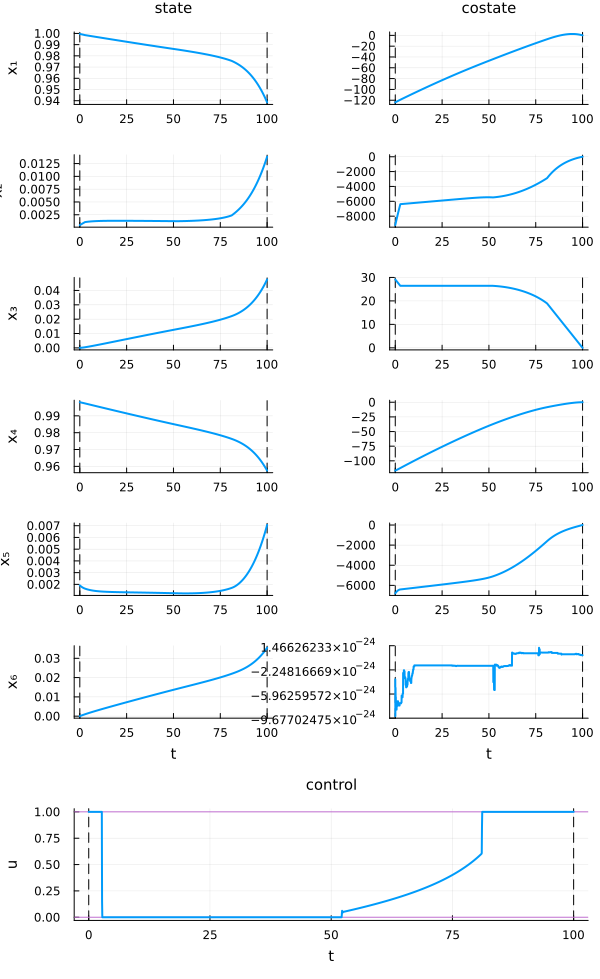

┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\PC\.julia\packages\PlotUtils\dVEMd\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\PC\.julia\packages\PlotUtils\dVEMd\src\ticks.jl:194


LoadError: TypeError: in keyword argument layout, expected Symbol, got a value of type Matrix{Any}

In [38]:
#Parámetros del sistema
beta1 = 0.10 #tasa de transmisión de la enfermedad fuera de la escuela
beta2 = 0.15 #tasa de transmisión de la enfermedad dentro de la escuela
gamma  = 0.20 #tasa de recuperación de la enfermedad
lambdaE = 1 #ponderador de beneficio de la apertura
lambdaI = 50 #ponderador de penalización de infectados
T  = 100  #duración de la simulación

#Definimos el problema de control óptimo
ocp = @def begin
    t ∈ [0, T], time
    x ∈ R⁶, state      #los 6 estados del modelo [SE, IE, RE, SNE, INE, RNE]
    u ∈ R, control     #control cuantifica la reapertura de la escuela

    #Condiciones iniciales
    x(0) == [0.999521, 0.000479, 0.0, 0.998086, 0.001914, 0.0]

    #Dinámica del modelo
    ẋ(t) == [
        -beta1 * x₁(t) * (x₂(t) + x₅(t)) - u(t) * beta2 * x₁(t) * x₂(t),               # ecuación SE'
         beta1 * x₁(t) * (x₂(t) + x₅(t)) + u(t) * beta2 * x₁(t) * x₂(t) - gamma*x₂(t),   # ecuación IE'
         gamma * x₂(t),                                                                # ecuación RE'
        -beta1 * x₄(t) * (x₂(t) + x₅(t)),                                              # ecuación SNE'
         beta1 * x₄(t) * (x₂(t) + x₅(t)) - gamma * x₅(t),                              # ecuación INE'
         gamma * x₅(t)                                                                 # ecuación RNE'
    ]

    #Defino la función objetivo (minimizar J(u))
    ∫(lambdaE * u(t) * (x₁(t) + x₃(t)) - lambdaI * (x₂(t) + x₅(t)) ) → max

    #Restricciones para el control
    0 ≤ u(t) ≤ 1 
end

#Resolver el problema
sol2 = solve(ocp, grid_size=2000)

#Graficar resultados
p1 = plot(sol2, vars=(0, :u), title="Control óptimo u(t)", xlabel="Tiempo", ylabel="Apertura")
display(p1)

p2 = plot(sol2, vars=(0, 1:6), layout = @layout([a b; c d; e f]),title="Evolución de estados", legend=false)
display(p2)

**Número efectivo reproductivo**

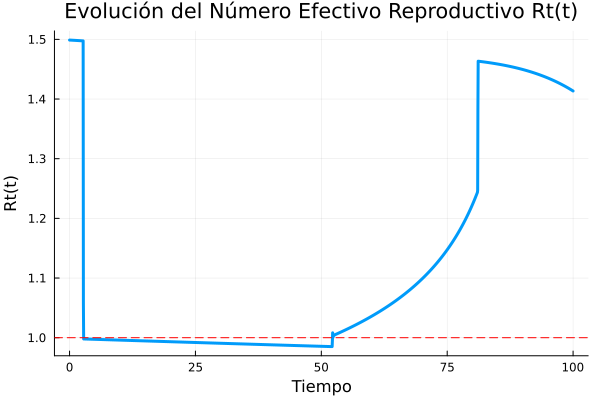

In [39]:
# Definición de la función Rt(t) usando la Matriz de Siguiente Generación (NGM)
function calculoRt(state, u, β1, β2, γ)
    SE, IE, RE, SNE, INE, RNE = state

    # Matriz F (nuevas infecciones)
    F = [
        (β1 + u * β2) * SE       β1 * SE
        β1 * SNE                 β1 * SNE
    ]

    # Matriz de Siguiente Generación K = F * V⁻¹ = F / γ
    K = F / γ
    
    # Valores propios
    vals = eigvals(K)
    
    # Rt es el valor propio más grandes
    return maximum(abs.(vals)) 
end


ts = sol2.time_grid.value       # vector de tiempos discretos
state_fun = sol2.state.value    # función interpolada del estado x(t)
control_fun = sol2.control.value # función interpolada del control u(t)


#Calcular Rt(t)
Rt_vals = [calculoRt(state_fun(t), control_fun(t), beta1, beta2, gamma) for t in ts]

# Graficar el resultado
p4 = plot(ts, Rt_vals, 
    xlabel="Tiempo", ylabel="Rt(t)", 
    title="Evolución del Número Efectivo Reproductivo Rt(t)",
    label=false,
    linewidth=3)

#Añadir la línea crítica Rt = 1
hline!([1], line=:dash, color=:red, label=false) 

display(p4)
    

**Función de conmutación**

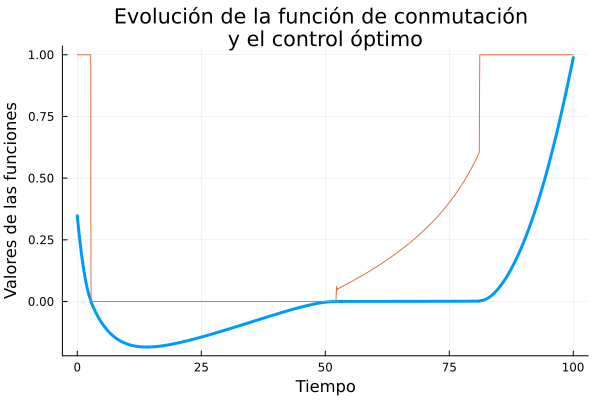

In [40]:
# Definición de la función phi(t) de conmutación dada por el principio del máximo de Pontryagin
function conmutación(state, costate, lambda, β2)
    SE, IE, RE, SNE, INE, RNE = state
    p1, p2, p3, p4, p5, p6 = costate

    phi = lambda*( SE + RE ) + ( -p1 + p2 ) * β2 * SE * IE

    return phi
end


ts2 = sol2.time_grid.value       # vector de tiempos discretos
state_fun2 = sol2.state.value    # función interpolada del estado x(t)
costate_fun2 = sol2.costate # función interpolada del control u(t)


#Calcular phi(t)
phi_vals2 = [conmutación(state_fun2(t), costate_fun2(t), lambdaE, beta2) for t in ts]
control_fun2 = sol2.control.value
control_vals2 = [control_fun2(t) for t in ts]

using Plots, LaTeXStrings
# Graficar el resultado
p5 = plot(ts2, phi_vals2, 
    xlabel="Tiempo", ylabel="Valores de las funciones", 
    title="Evolución de la función de conmutación \n y el control óptimo ",
    label=false,
    linewidth=3)
plot!(ts2, control_vals2, label = false)

display(p5)